In [6]:
import os

# Core LSD imports
from sclsd.train import LSD
from sclsd.plotting import plot_random_walks
from sclsd.analysis import cross_boundary_correctness
from cellrank.kernels import ConnectivityKernel
from cellrank.kernels.utils import TmatProjection



from sclsd.core import LSDConfig
from sclsd.utils import set_all_seeds
from sclsd.utils.seed import clear_pyro_state

# Deep learning
import torch

# Single-cell analysis
import scanpy as sc

import numpy as np
import pandas as pd


print(f"PyTorch version: {torch.__version__}")
print(f"Scanpy version: {sc.__version__}")

# Configure computational device
device = torch.device("cuda:3" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
SEED = 42
set_all_seeds(SEED)

PyTorch version: 2.4.1+cu121
Scanpy version: 1.11.5
Using device: cuda:3


In [2]:
adata = sc.read("../../Zenodo/Neurogenesis/preprocessed_adata.h5ad")
adata

AnnData object with n_obs × n_vars = 40559 × 300
    obs: 'orig.ident', 'nCount_Vizgen', 'nFeature_Vizgen', 'z', 'volume', 'fov', 'nCount_SCT', 'nFeature_SCT', 'seurat_clusters', 'Sample_ID', 'Estimated_postconceptional_age_in_days', 'Group', 'Region', 'Region_details', 'integrated_snn_res.2.8', 'class', 'subclass', 'type', 'nCount_niche', 'nFeature_niche', 'niches', 'niche_name', 'type_updated', 'x', 'y', 'prior_pseudotime', 'clusters', 'librarysize'
    uns: 'log1p', 'neighbors', 'pca', 'subclass_colors'
    obsm: 'X_pca', 'X_umap', 'spatial'
    varm: 'PCs'
    layers: 'raw'
    obsp: 'connectivities', 'distances'

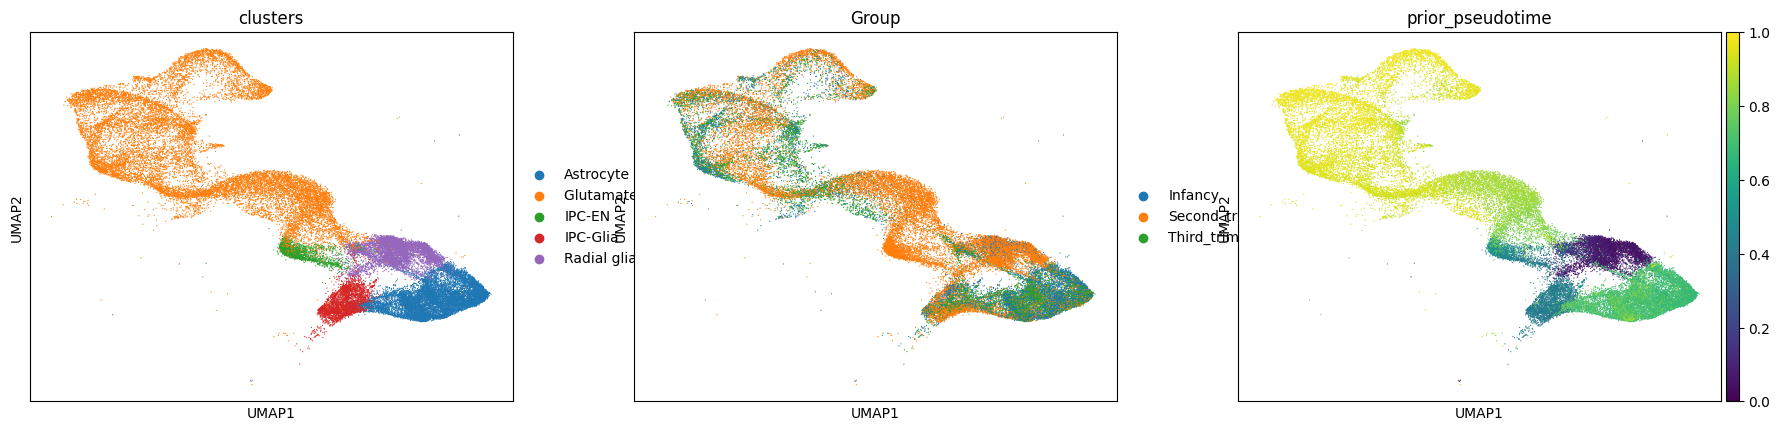

In [3]:
sc.pl.umap(adata, color = ["clusters", "Group", "prior_pseudotime"])

In [4]:
# Initialize the LSD model
cfg = LSDConfig()
cfg.walks.random_state = SEED
cfg.walks.num_walks = 8192
cfg.walks.path_len = 16
cfg.walks.batch_size = 1024

lsd = LSD(
    adata,
    cfg,            
    device=device,                   
)
# Define model directory based on hyperparameters
model_dir = "./model"

# Clear parameter store for fresh training
clear_pyro_state()
# Create save directory
model_path = "lsd_model_epoch0120.pth"
lsd.load(model_dir, model_path)
#extract LSD outputs (transition matrix, potantial, entropy, pseudotime)
final_adata = lsd.get_adata()

#predict cell fates
dyn_adata = lsd.get_cell_fates(final_adata , time_range = 5, cluster_key = "clusters")

[LSD] Model and Pyro parameters loaded from ./model/lsd_model_epoch0120.pth


/scratch/apour/conda/envs/sclsd/lib/python3.10/site-packages/sclsd/train/trainer.py:894: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  predicted_fates = adata.obs[cluster_key][nn.cpu().numpy()].values


plotting LSD outputs on UMAP projection


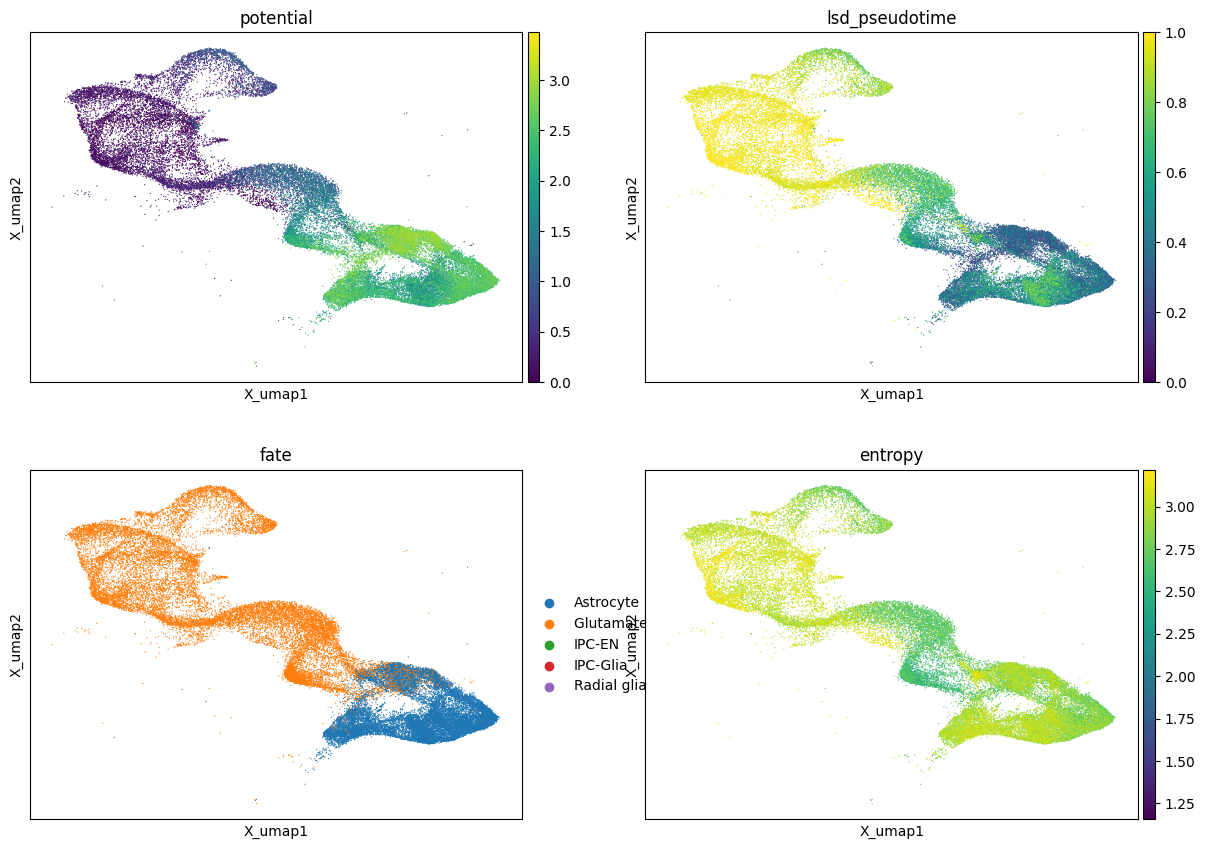

plotting LSD outputs on diffrentiation state projection


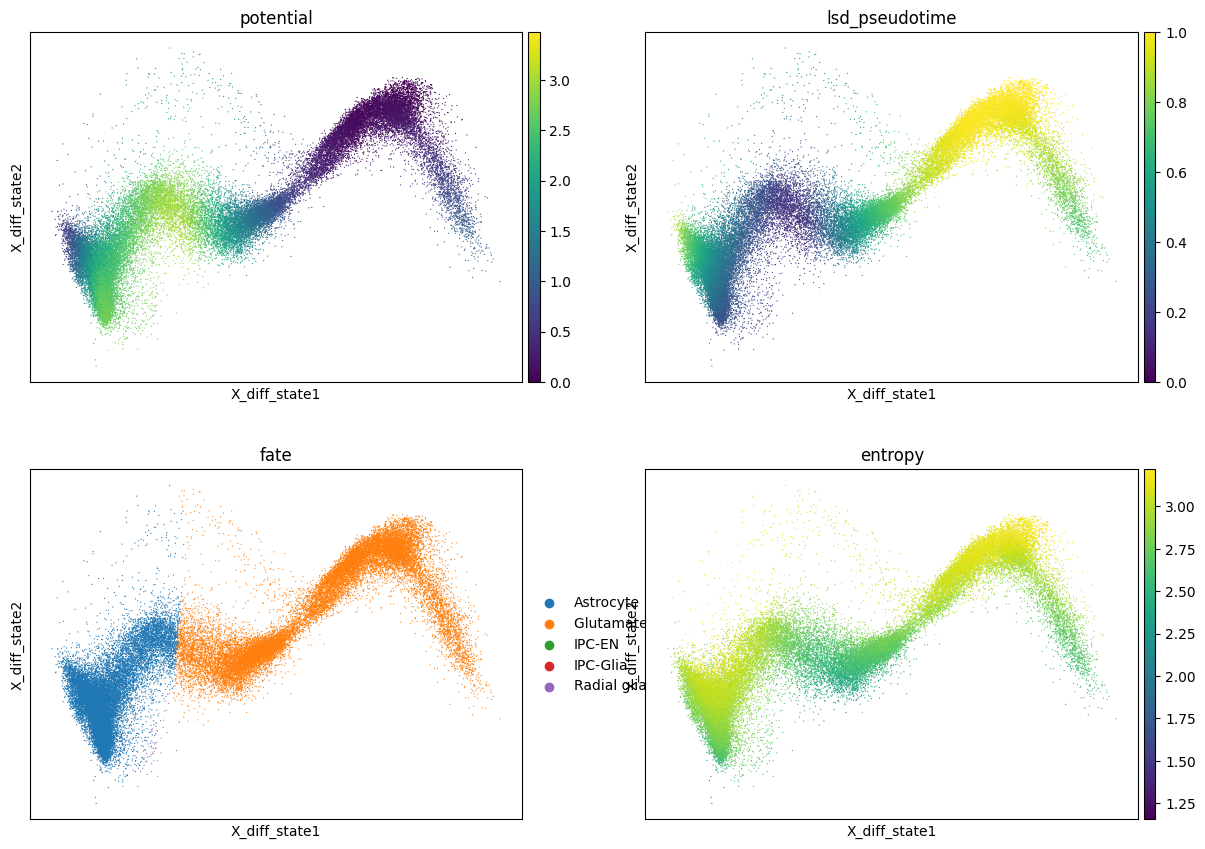

plotting LSD streamlines on UMAP projection


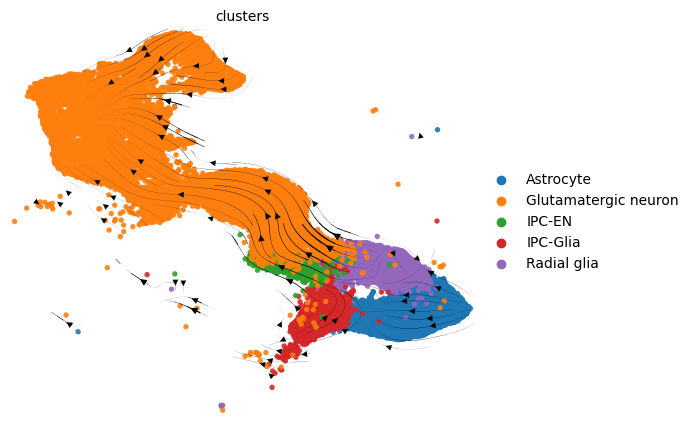

plotting LSD streamlines on diffrentiation state projection


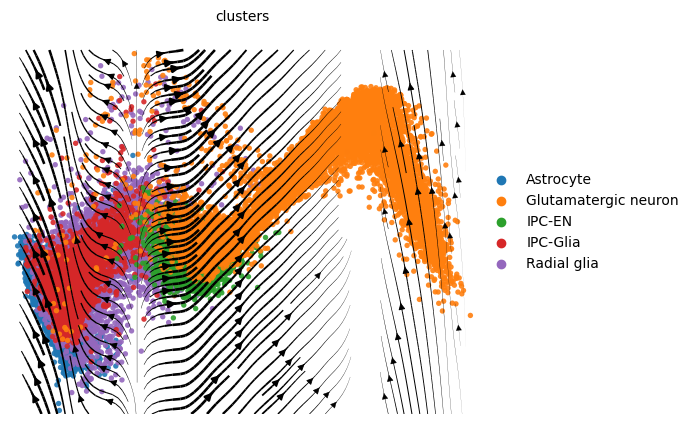

<Axes: title={'center': 'clusters'}>

In [8]:
#plot lsd outputs
dyn_adata.uns["fate_colors"] = dyn_adata.uns["clusters_colors"]
cols = ["potential", "lsd_pseudotime", "fate", "entropy"]

print("="* 60)
print("plotting LSD outputs on UMAP projection")
print("="* 60)
sc.pl.embedding(dyn_adata, color = cols, basis = "X_umap", ncols = 2)

print("="* 60)
print("plotting LSD outputs on diffrentiation state projection")
print("="* 60)
sc.pl.embedding(dyn_adata, color = cols, basis = "X_diff_state", ncols = 2)

print("="* 60)
print("plotting LSD streamlines on UMAP projection")
print("="* 60)
lsd.stream_lines(embedding= "X_umap", size = 60)

print("="* 60)
print("plotting LSD streamlines on diffrentiation state projection")
print("="* 60)
lsd.stream_lines(embedding= "X_diff_state", size = 60)

In [8]:
cluster_edges = [
    ("Radial glia", "IPC-EN"),
    ("Radial glia", "IPC-Glia"),
    ("Radial glia", "Glutamatergic neuron"),
    ("IPC-EN", "Glutamatergic neuron"),
    ("IPC-Glia", "Astrocyte"),
]

final_adata.obsm["X_umap_eval"] = np.asarray(final_adata.obsm["X_umap"])

kernel = ConnectivityKernel(final_adata)
kernel.transition_matrix = final_adata.obsp["transitions"]

proj = TmatProjection(kernel, basis="X_umap_eval")
proj.project(
    key_added="velocity_umap",
    recompute=True,
    connectivities=final_adata.obsp["connectivities"],
)

final_adata.uns.setdefault("neighbors", {})
final_adata.uns["neighbors"]["indices"] = final_adata.obsp["distances"].tolil().rows

all_scores, mean_cbdir = cross_boundary_correctness(
    final_adata,
    k_cluster="clusters",
    k_velocity="velocity_umap",
    cluster_edges=cluster_edges,
    x_emb="X_umap_eval",
)

cbdir_df = pd.DataFrame(
    {
        "edge": [f"{src}->{dst}" for src, dst in all_scores],
        "cbdir": list(all_scores.values()),
    }
)

print("Cross-boundary correctness scores:")
for edge, score in all_scores.items():
    print(f"  {edge}: {score:.3f}")
print(f"\nOverall average: {mean_cbdir:.3f}")

cbdir_df

Cross-boundary correctness scores:
  ('Radial glia', 'IPC-EN'): 0.439
  ('Radial glia', 'IPC-Glia'): -0.097
  ('Radial glia', 'Glutamatergic neuron'): 0.615
  ('IPC-EN', 'Glutamatergic neuron'): 0.337
  ('IPC-Glia', 'Astrocyte'): 0.184

Overall average: 0.296


,edge,cbdir
0,Radial glia->IPC-EN,0.439410
1,Radial glia->IPC-Glia,-0.097496
2,Radial glia->Glutamatergic neuron,0.615428
3,IPC-EN->Glutamatergic neuron,0.337080
4,IPC-Glia->Astrocyte,0.183706
